## Цель исследования

Провести комплексный анализ ассортимента обуви интернет-магазина «Спорт-Марафон»:  
- изучить структуру ассортимента по брендам, типам обуви и категориям пола;  
- проанализировать распределение цен и скидок;  
- выявить особенности размерных рядов;  
- проверить гипотезы о влиянии полноты размерного ряда и популярности брендов на глубину скидки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Основной цвет (фиолетовый)
main_color = plt.cm.Purples(0.6)

# Цветовая палитра для seaborn (градиент)
palette = 'Purples_d'

# Настройки seaborn
sns.set_style('whitegrid')
sns.set_palette(palette)

# Для сравнения двух категорий (оранжевый / фиолетовый)
comparison_palette = ['#d95f02', '#7570b3']

# Глобальные настройки matplotlib
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 20,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 1.5,
    'figure.figsize': (10, 6),
})

# Цикл цветов для matplotlib (один цвет для всех элементов)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[main_color])

In [3]:
df = pd.read_csv('sportmarafon_shoes_2026-05-13.csv')
df.head()

,brand,name,price,old_price,sizes
0,Nike,Кроссовки мужские Nike Vomero Premium White/Bl...,39980,NaN,"['44', '46', '47']"
1,Hoka,Кроссовки женские Hoka Bondi 9 Lingon Berry/Cr...,24480,NaN,"['37(1/3)', '38', '38(2/3)', '39(1/3)', '40', ..."
2,Salomon,Кроссовки мужские Salomon Aero Glide 4 Bluing/...,20980,NaN,"['41(1/3)', '42', '43(1/3)', '44', '44(2/3)', ..."
3,Salomon,Кроссовки женские Salomon Aero Glide 4 Vanilla...,20980,NaN,"['38', '38(2/3)', '42']"
4,Asics,Кроссовки мужские ASICS Gel-Nimbus 28 Cold Mos...,20980,NaN,"['40(1/2)', '41(1/2)', '42', '42(1/2)', '43(1/..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1488 entries, 0 to 1487
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   brand      1488 non-null   object 
 1   name       1488 non-null   object 
 2   price      1488 non-null   int64  
 3   old_price  495 non-null    float64
 4   sizes      1488 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 58.2+ KB


# 1. Предобработка

## 1.1. Дубли и пропуски

In [5]:
print('Найдено дублей:', df.duplicated().sum())

Найдено дублей: 0


In [6]:
print(df.isnull().sum())

brand          0
name           0
price          0
old_price    993
sizes          0
dtype: int64


In [7]:
df['old_price'] = df['old_price'].fillna(0)

## 1.2. Добавление новых признаков

### 1.2.1. Тип (type)

In [8]:
df['type'] = df['name'].str.split().str[0].str.strip()

In [9]:
df['type'] = df['type'].str.replace('Cапоги', 'Сапоги')

In [10]:
problematic = ['Скальные', 'Резиновые', 'Пуховые']

mask = df['type'].isin(problematic)
df.loc[mask, 'type'] = df.loc[mask, 'name'].apply(lambda x: ' '.join(x.split()[:2]))

In [11]:
accessories_keywords = ['Стельки', 'Шнурки', 'Гамаши', 'Бахилы', 'Ледоступы', 
                        'Кошки', 'Вставка', 'Шип', 'Тросики', 'Ключ', 'Ложка', 
                        'Защита', 'Пуховые', 'Стелька']

df_accessories = df[df['type'].isin(accessories_keywords)]
df = df[~df['type'].isin(accessories_keywords)]

In [12]:
df['type'] = df['type'].replace('Резиновые сапоги', 'Сапоги')
df['type'] = df['type'].replace('Тапки', 'Пуховые тапки')

In [13]:
print('Финальные типы обуви:', df['type'].unique())

Финальные типы обуви: ['Кроссовки' 'Ботинки' 'Пуховые тапки' 'Сапоги' 'Сандалии']


### 1.2.2. Пол (gender)

In [14]:
def set_gender (name):
    gender = name.split()[1].strip()
    if gender == 'мужские':
        return 'Мужской'
    elif gender == 'женские':
        return 'Женский'
    elif gender == 'детские':
        return 'Детский'
    elif gender == 'сапоги':
        return 'Детский'
    else:
        return 'Унисекс'

df['gender'] = df['name'].apply(set_gender)

### 1.2.3. Скидка (discount)

In [15]:
def calc_discount(row):
    if row['old_price'] > 0 and row['price'] > 0:
        discount = row['old_price'] - row['price']
        return round(discount, 1)
    else:
        return 0

df['discount'] = df.apply(calc_discount, axis=1)

### 1.2.4. Процент скидки (discount_percent)

In [16]:
def calc_discount_per(row):
    if row['old_price'] > 0 and row['price'] > 0:
        discount = (row['old_price'] - row['price']) / row['old_price'] * 100
        return round(discount, 1)
    else:
        return 0

df['discount_percent'] = df.apply(calc_discount_per, axis=1)

### 1.2.5. Преобразование столбца размеры (sizes)

In [17]:
import ast
df['sizes'] = df['sizes'].apply(ast.literal_eval)

### 1.2.6. Количество размеров (size_count)

In [18]:
df['size_count'] = df['sizes'].apply(len)

## 1.3. Проверка типов и значений

In [19]:
df.dtypes

brand                object
name                 object
price                 int64
old_price           float64
sizes                object
type                 object
gender               object
discount            float64
discount_percent    float64
size_count            int64
dtype: object

In [20]:
if (df['price'] < 0).any():
    print('Внимание: обнаружены отрицательные цены!')

# 2. Исследовательский анализ

## 2.1. Распределения основных признаков

### 2.1.1. Цены

In [21]:
df['price'].describe()

count      1395.000000
mean      19977.657348
std       10296.119232
min         894.000000
25%       14465.000000
50%       19290.000000
75%       24390.000000
max      111000.000000
Name: price, dtype: float64

In [22]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = max(0, Q1 - 1.5 * IQR)
upper = Q3 + 1.5 * IQR
print(f'Основная масса без выбросов: от {lower:.0f} до {upper:.0f}')

Основная масса без выбросов: от 0 до 39278


In [23]:
len(df[df['price'] > upper])

45

In [24]:
lower = df['price'].quantile(0.05)
upper = df['price'].quantile(0.95)
print(f'90% товаров лежит между {lower:.0f} и {upper:.0f}')

90% товаров лежит между 5248 и 35990


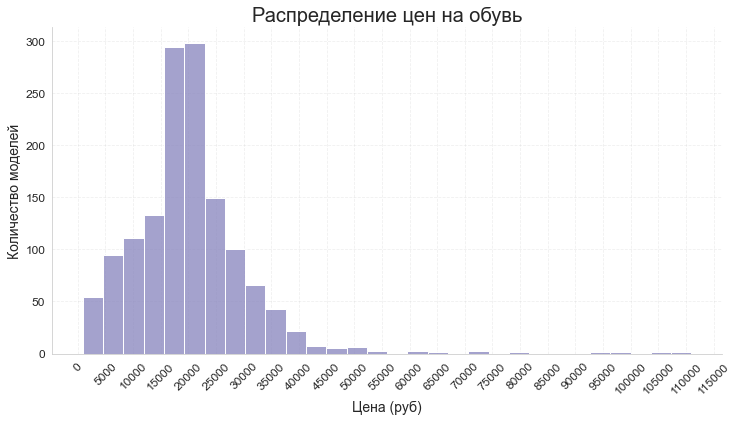

In [25]:
plt.figure(figsize=(12,6))
sns.histplot(df['price'], bins=30)
plt.title('Распределение цен на обувь')
plt.xlabel('Цена (руб)')
plt.ylabel('Количество моделей')
plt.locator_params(axis='x', nbins=30)
plt.xticks(rotation=45)
plt.show()

**Вывод:**  
- 90% товаров стоят от 5 248 до 35 990 руб (5‑й и 95‑й персентили).
- Половина моделей дешевле 19 290 руб (медиана), пик распределения — около 20 000 руб.
- Самые дорогие 25% товаров — от 24 390 руб.
- Выбросы (более 39 278 руб. по критерию IQR) составляют 45 моделей.
- Максимальная цена — 111 000 руб.
- Самая дорогая обувь — Ботинки Zamberlan 8000 Everest Evo RR PU Black/Orange.

### 2.1.2. Бренды

In [26]:
df['brand'].nunique()

48

In [27]:
df['brand'].value_counts().head(10)

brand
Altra             154
Salomon           107
Mizuno             94
Scarpa             70
Hoka               70
Asics              68
LOWA               64
The North Face     59
Saucony            58
La Sportiva        57
Name: count, dtype: int64

In [28]:
df['brand'].value_counts().tail(3)

brand
Dynafit    1
Kailas     1
Lomer      1
Name: count, dtype: int64

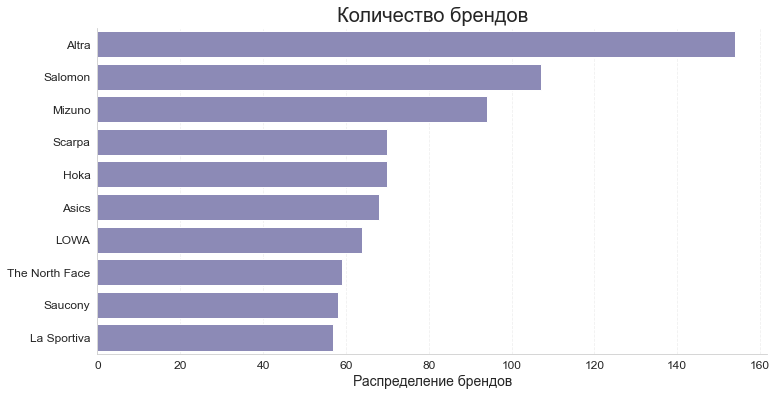

In [29]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='brand', order=df['brand'].value_counts().head(10).index)
plt.xlabel('Распределение брендов')
plt.ylabel('')
plt.title('Количество брендов')
plt.show()

In [30]:
df['brand'].value_counts(normalize=True).mul(100).round(2).head(3)

brand
Altra      11.04
Salomon     7.67
Mizuno      6.74
Name: proportion, dtype: float64

**Вывод:**  
- Количество брендов: 48.
- Топ-3 по числу моделей: Altra (154), Salomon (107), Mizuno (94).
- На бренды Altra приходится 11,04% ассортимента, на бренд Salomon — 7,67%, на Mizuno — 6,74%.
- Самые редкие бренды: Dynafit, Kailas и Lomer. На них приходится по одной модели обуви.

### 2.1.3. Тип обуви

In [31]:
df['type'].value_counts()

type
Кроссовки        746
Ботинки          498
Сандалии          79
Сапоги            64
Пуховые тапки      8
Name: count, dtype: int64

In [32]:
df['type'].value_counts(normalize=True).mul(100).round(2)

type
Кроссовки        53.48
Ботинки          35.70
Сандалии          5.66
Сапоги            4.59
Пуховые тапки     0.57
Name: proportion, dtype: float64

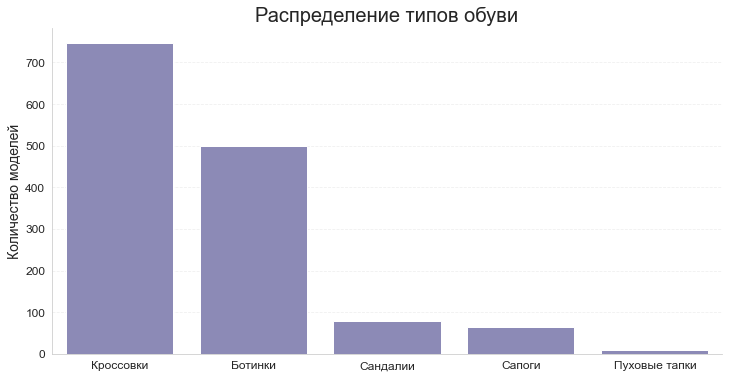

In [33]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.xlabel('')
plt.ylabel('Количество моделей')
plt.title('Распределение типов обуви')
plt.show()

**Вывод:**  
- Всего 5 типов обуви: Кроссовки, Ботинки, Сандалии, Сапоги и Пуховые тапки.
- В ассортименте явно преобладают Кроссовки (746 моделей) и Ботинки (498 моделей). На них приходится более 89% ассортимента.

### 2.1.4. Пол

In [34]:
df['gender'].value_counts()

gender
Мужской    629
Женский    544
Детский    114
Унисекс    108
Name: count, dtype: int64

In [35]:
df['gender'].value_counts(normalize=True).mul(100).round(0)

gender
Мужской    45.0
Женский    39.0
Детский     8.0
Унисекс     8.0
Name: proportion, dtype: float64

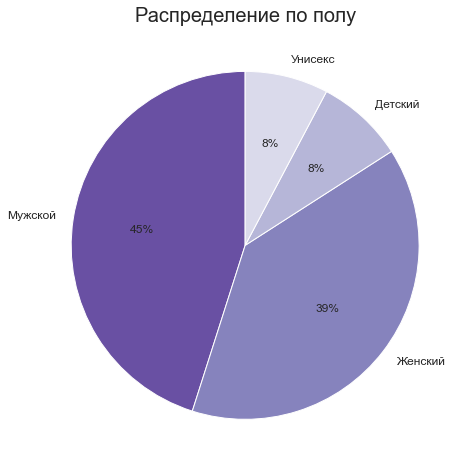

In [36]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.0f%%', startangle=90,
        colors=plt.cm.Purples([0.75, 0.6, 0.4, 0.25]), textprops={'fontsize': 12})
plt.title('Распределение по полу')
plt.show()

**Вывод:**  
Мужская обувь занимает 45% ассортимента (629 моделей), женская — 39% (544 модели). Детская и унисекс представлены значительно меньше — по 8% (114 и 108 моделей).

### 2.1.5. Скидки

In [37]:
total = len(df)
with_discount = len(df[df['discount_percent'] > 0])
without_discount = total - with_discount
print(f"Товаров со скидкой: {with_discount} ({with_discount/total*100:.1f}%)")
print(f"Без скидки: {without_discount} ({without_discount/total*100:.1f}%)")

Товаров со скидкой: 453 (32.5%)
Без скидки: 942 (67.5%)


In [38]:
df_disc = df[df['discount_percent'] > 0].copy()

In [39]:
df_disc['discount'].describe()

count      453.000000
mean      8599.885210
std       4595.727264
min       1347.000000
25%       5997.000000
50%       7896.000000
75%      10600.000000
max      33512.000000
Name: discount, dtype: float64

In [40]:
df_disc['discount_percent'].describe()

count    453.000000
mean      35.860927
std       10.301241
min       15.000000
25%       30.000000
50%       40.000000
75%       40.000000
max       60.000000
Name: discount_percent, dtype: float64

In [41]:
df_disc['discount_percent'].value_counts().sort_values(ascending=False)

discount_percent
30.0    148
40.0    141
50.0     83
20.0     70
60.0     10
15.0      1
Name: count, dtype: int64

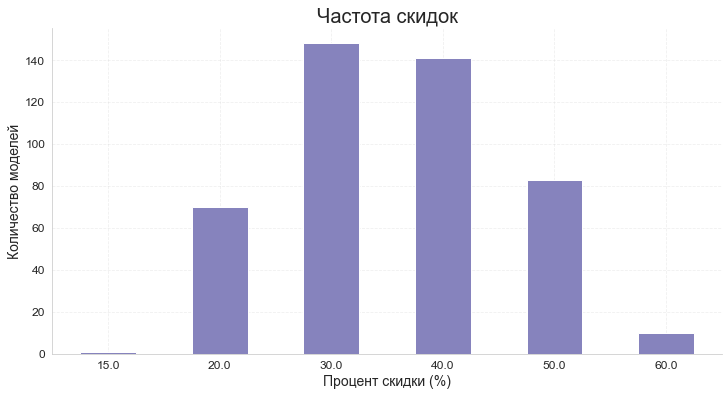

In [42]:
plt.figure(figsize=(12, 6))
df_disc['discount_percent'].value_counts().sort_index().plot(kind='bar')
plt.title('Частота скидок')
plt.xlabel('Процент скидки (%)')
plt.ylabel('Количество моделей')
plt.xticks(rotation=360)
plt.show()

**Вывод:**  
- Скидка предоставлена на 32,5% товаров (453 модели). 
- Скидки варьируются от 15% до 60% (медиана — 40%, средняя — 35,9%).
- Средняя скидка в рублях — 8 600 руб.
- Максимальная скидка достигает 60% (33 512 руб).
- Скидки не распределены непрерывно, а концентрируются вокруг «круглых» значений: 30% и 40% встречаются чаще всего (148 и 141 модель соответственно), скидки 50%, 20%, 60% и 15% заметно реже.

### 2.1.6. Размеры

In [43]:
sizes_expanded = df['sizes'].explode()

In [44]:
size_counts = sizes_expanded.value_counts().sort_index()
size_counts

sizes
20          1
22          3
23          1
24          6
25          9
           ..
48(1/3)     9
49         31
49(1/2)     1
49(1/3)    25
50          8
Name: count, Length: 78, dtype: int64

In [45]:
size_counts.nlargest(10)

sizes
42         652
44         458
42(1/2)    443
46         423
38         420
44(1/2)    408
45         392
40         370
41         322
43         319
Name: count, dtype: int64

In [46]:
df[['name', 'size_count']].sort_values('size_count', ascending=False).head(1)

,name,size_count
57,Ботинки мужские Scarpa Mojito Fossil,20


**Вывод:**  
- Всего размеров: 78.
- Диапазон размеров: от 20 до 50.
- Топ-10 популярных размеров: 42, 44, 42(1/2), 46, 38, 44(1/2), 45, 40, 41, 43
- Обувь с самым широким размерным рядом (20 размеров): Ботинки мужские Scarpa Mojito Fossil.

## 2.2. Анализ по группам

### 2.2.1. Цены по брендам

In [47]:
brand_count_mean = df.groupby('brand')['price'].agg(['count', 'mean']).round(2).sort_values('mean', ascending=False)
brand_count_mean

,count,mean
brand,,
Kailas,1,92980.00
Zamberlan,21,46049.48
Hanwag,40,31116.70
Nike,22,30889.09
La Sportiva,57,30861.23
LOWA,64,30605.00
Meindl,34,29590.76
Asolo,41,29176.15
Anta,15,24363.33


In [48]:
top_brands = brand_count_mean[brand_count_mean['count'] >= 10].head(15)
top_brands

,count,mean
brand,,
Zamberlan,21,46049.48
Hanwag,40,31116.70
Nike,22,30889.09
La Sportiva,57,30861.23
LOWA,64,30605.00
Meindl,34,29590.76
Asolo,41,29176.15
Anta,15,24363.33
Scarpa,70,23554.37


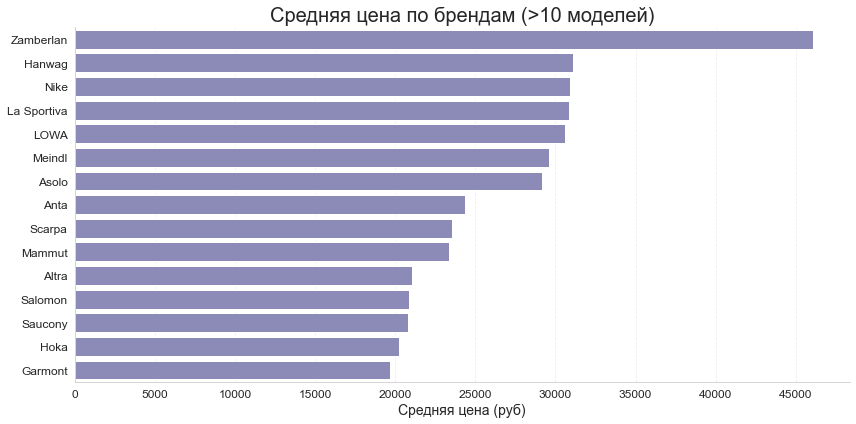

In [49]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_brands, y=top_brands.index, x='mean')
plt.title('Средняя цена по брендам (>10 моделей)')
plt.xlabel('Средняя цена (руб)')
plt.ylabel('')
plt.locator_params(axis='x', nbins=10)
plt.tight_layout()
plt.show()

**Вывод:**  
- Среди брендов, представленных более чем 10 моделями, самые дорогие — Zamberlan (46 049 руб, 21 модель), Hanwag (31 117 руб, 40), Nike (30 889 руб, 22). Самые бюджетные — Lassie (3 837 руб, 44), Teva (6 722 руб, 34) и Joma (2 515 руб, 11). 
- Бренд Kailas с единственной моделью показал экстремально высокую цену (92 980 руб).

### 2.2.2. Цены по полу

In [50]:
df.groupby('gender')['price'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Детский,114.0,5872.14,3603.93,894.0,2999.0,4995.0,7987.5,14990.0
Женский,544.0,19869.93,7807.56,5586.0,14693.0,19290.0,23980.0,71984.0
Мужской,629.0,21913.78,8649.80,5586.0,17090.0,19990.0,25984.0,92980.0
Унисекс,108.0,24133.32,19167.84,4263.0,15192.0,18203.5,24990.0,111000.0


In [51]:
df.groupby('gender')['price'].quantile([0.05, 0.95]).unstack()

,0.05,0.95
gender,,
Детский,1645.0,13280.0
Женский,8740.0,33330.0
Мужской,8514.6,36662.4
Унисекс,7119.5,63968.2


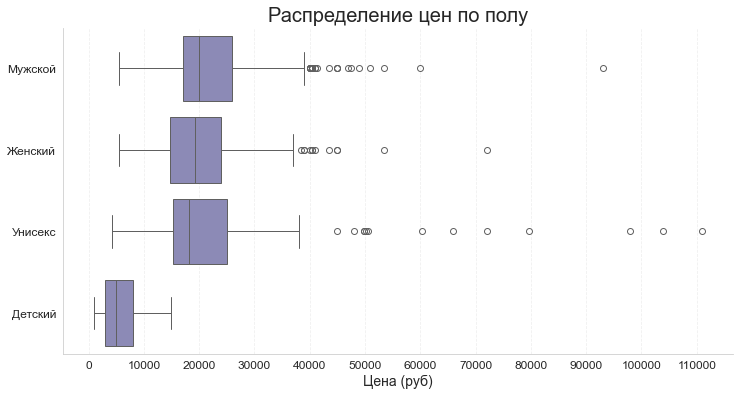

In [52]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, y='gender', x='price')
plt.title('Распределение цен по полу')
plt.xlabel('Цена (руб)')
plt.ylabel('')
plt.locator_params(axis='x', nbins=14)
plt.show()

**Вывод:**  
- Детская обувь значительно дешевле взрослой (средняя цена 5 872 руб, медиана 4 995 руб). Типичная цена от 1 645 до 13 280 руб.
- Мужская и женская обувь близки по цене: средняя цена мужской — 21 914 руб, женской — 19 870 руб, медианы — 19 990 и 19 290 руб соответственно. Типичная цена мужской обуви от 8 515 до 36 662 руб, женской — от 8 740 до 33 330 руб.
- Обувь категории унисекс имеет самую высокую среднюю цену (24 133 руб), но медиана (18 204 руб) ниже, чем у мужской и женской. Это указывает на наличие дорогих выбросов (максимум 111 000 руб), которые поднимают среднее. Типичная цена обуви унисекс от 7 120 до 63 968 руб.



### 2.2.3. Скидки по брендам

In [53]:
df_disc['brand'].value_counts().head(10)

brand
Lassie      37
Mizuno      33
AKU         30
Hoka        28
Hanwag      27
Dolomite    26
Garmont     23
Altra       21
Kayland     19
Scarpa      19
Name: count, dtype: int64

In [54]:
brand_discount = df_disc.groupby('brand')['discount_percent'].agg(['count', 'mean']).round(2).sort_values('mean', ascending=False)
top_brands_disc = brand_discount[brand_discount['count'] > 5].head(10)
top_brands_disc

,count,mean
brand,,
Lassie,37,49.19
Aigle,8,48.75
Bestard,6,46.67
AKU,30,42.00
Joma,11,41.82
Kayland,19,41.58
Icebug,7,40.00
Asics,6,40.00
Altra,21,39.05


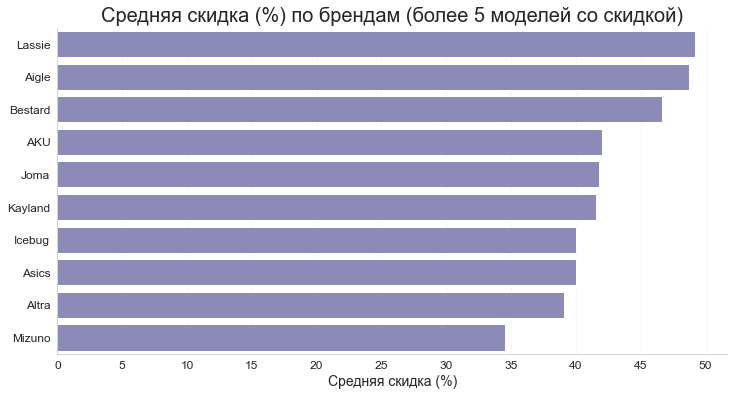

In [55]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_brands_disc, y=top_brands_disc.index, x='mean')
plt.title('Средняя скидка (%) по брендам (более 5 моделей со скидкой)')
plt.xlabel('Средняя скидка (%)')
plt.ylabel('')
plt.locator_params(axis='x', nbins=12)
plt.show()

In [56]:
df_disc.groupby('brand')['discount_percent'].max().sort_values(ascending=False).head(10)

brand
Kamik               60.0
Viking              60.0
Reebok              60.0
Lomer               60.0
Kayland             60.0
Ecco                60.0
Jog Dog             50.0
Ventesima Strada    50.0
Sorel               50.0
Scarpa              50.0
Name: discount_percent, dtype: float64

**Вывод:**  
- Чаще всего скидки встречаются на бренды: Lassie (37 моделей), Mizuno (33 модели), AKU (30 моделей).
- Средняя скидка среди брендов, у которых на скидке не менее 5 моделей, максимальна у Lassie (49,2%), Aigle (48,8%) и Bestard (46,7%).
- Максимальная скидка (60%) встречается у брендов: Kamik, Viking, Reebok, Lomer, Kayland, Ecco

### 2.2.4. Скидки по полу

In [57]:
df_disc.groupby('gender')['discount_percent'].agg(['count', 'mean', 'median']).round(2).sort_values('mean', ascending=False)

,count,mean,median
gender,,,
Детский,62,48.23,50.0
Женский,184,34.78,30.0
Мужской,166,33.40,30.0
Унисекс,41,31.95,30.0


In [58]:
df.groupby('gender')['discount_percent'].apply(lambda x: (x > 0).sum() / len(x) * 100).round(2)

gender
Детский    54.39
Женский    33.82
Мужской    26.39
Унисекс    37.96
Name: discount_percent, dtype: float64

**Вывод:**  
- Скидки чаще всего встречаются на женской обуви (184 модели).
- Самые высокие средние скидки — у детской обуви (48,2%), тогда как у женской, мужской и унисекс они составляют около 30–35%.
- Типичная скидка (медиана) на детскую обувь достигает 50%, на остальные категории — 30%.
- Доля товаров со скидкой максимальна среди детской обуви (54,4%), далее следуют унисекс (38%), женская (33,8%) и мужская (26,4%).

### 2.2.5. Размеры по типу обуви

In [59]:
df_exp = df.explode('sizes')

In [60]:
df.groupby('type')['size_count'].mean().sort_values(ascending=False).round(1)

type
Кроссовки        6.3
Ботинки          5.9
Пуховые тапки    4.9
Сандалии         4.8
Сапоги           3.3
Name: size_count, dtype: float64

In [61]:
df_exp.groupby('type')['sizes'].agg(lambda x: x.mode()[0])

type
Ботинки               42
Кроссовки             42
Пуховые тапки         39
Сандалии         44(1/2)
Сапоги                29
Name: sizes, dtype: object

**Вывод:**  
- Самый полный размерный ряд — у кроссовок и ботинок (в среднем 6+ размеров на модель).
- Типичный (наиболее часто встречающийся) размер: 42 — для кроссовок и ботинок, 39 — для пуховых такпок, 44(1/2) — для сандалий и 29 — для сапог. 

### 2.2.6. Размеры по полу

In [62]:
df_exp.groupby('gender')['sizes'].agg(lambda x: x.mode()[0])

gender
Детский    29
Женский    38
Мужской    44
Унисекс    44
Name: sizes, dtype: object

In [63]:
df_exp.groupby('gender')['sizes'].agg(['min', 'max'])

,min,max
gender,,
Детский,20,41
Женский,36,44(1/2)
Мужской,37,50
Унисекс,35-38,48(1/3)


**Вывод:**  
Разброс размеров в женской обуви от 36 до 44(1/2), в мужской — от 37 до 50, в детской обуви — от 20 до 41, унисекс — от 35-38 до 48(1/3).
В женской обуви самые популярный размер 38, в мужской и унисекс — 44, в детской — 29.

### 2.2.7. Размеры по бренду

In [64]:
df.groupby('brand')['size_count'].mean().sort_values(ascending=False).round(1).head(10)

brand
LOWA       8.8
Bekina     8.8
Salomon    8.4
Asolo      8.4
Adidas     8.2
Meindl     7.4
Altra      7.4
Asics      7.4
Scarpa     6.7
Keen       6.6
Name: size_count, dtype: float64

In [65]:
df_exp.groupby('brand')['sizes'].agg(['min', 'max'])

,min,max
brand,,
AKU,37(1/2),47
Adidas,27(1/2),42
Aigle,28,48
Altra,37,49
Anta,37(1/2),46
Asics,27,49
Asolo,37(1/2),49
Bask,37-38,41-42
Bekina,37,47


**Вывод:**  
- Больше всего доступных размеров (в среднем более 8) у брендов: LOWA, Bekina, Salomon, Asolo, Adidas.
- Самый широкий размерный ряд — у Viking (от 20 до 47) и Mizuno (от 36 до 50). Бренды Kailas и Lomer представлены только одним размером.
- У брендов Crocs, Bask, Dynafit размеры указаны в виде диапазонов, что затрудняет сравнение размерных рядов.

### 2.2.8. Бренды по полу

In [66]:
df.groupby('gender')['brand'].nunique()

gender
Детский    11
Женский    35
Мужской    36
Унисекс    21
Name: brand, dtype: int64

In [67]:
brand_gender = df.groupby(['brand', 'gender']).size().unstack(fill_value=0)
brand_single = brand_gender[(brand_gender > 0).sum(axis=1) == 1]
brand_single

gender,Детский,Женский,Мужской,Унисекс
brand,,,,
Bask,0,0,0,2
Bekina,0,0,0,4
Crocs,0,0,0,4
Dynafit,0,0,0,1
Jog Dog,0,5,0,0
Joma,11,0,0,0
Kailas,0,0,1,0
Kamik,2,0,0,0
Lassie,44,0,0,0


In [68]:
brand_all = brand_gender[(brand_gender > 0).sum(axis=1) == 4]
brand_all

gender,Детский,Женский,Мужской,Унисекс
brand,,,,
Aigle,4,1,2,2
Scarpa,9,18,37,6
Viking,11,4,8,4


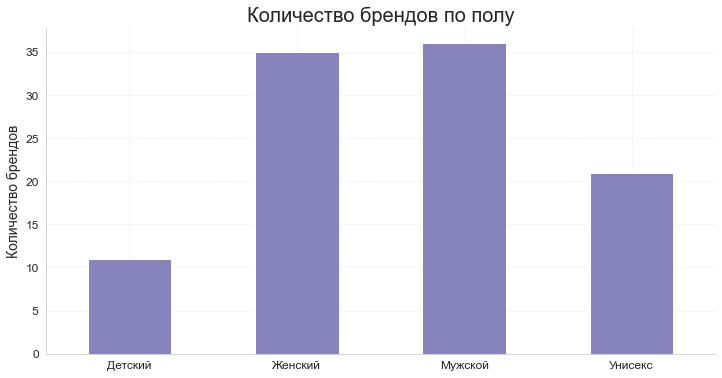

In [69]:
plt.figure(figsize=(12, 6))
df.groupby('gender')['brand'].nunique().plot(kind='bar')
plt.title('Количество брендов по полу')
plt.ylabel('Количество брендов')
plt.xlabel('')
plt.xticks(rotation=360)
plt.show()

**Вывод:**  
- Больше всего брендов представлено в категориях мужской (36) и женской (35) обуви. В унисекс — 21 бренд, в детской — 11.
- Специализированные бренды:
   * чисто детские — Joma, Kamik, Lassie, Reebok, Trezeta;
   * чисто женские — Jog Dog, Ventesima Strada;
   * чисто мужские — Lomer, Kailas (оба представлены одной моделью);
   * чисто унисекс — Bask, Bekina, Crocs, Dynafit (одна модель), Nora.
- Бренды, покрывающие все четыре категории (мужская, женская, детская, унисекс), — Aigle, Scarpa и Viking.

## 2.3. Комбинированный анализ

### 2.3.1. Цена по полу и типу

In [70]:
pivot_gend_type = df.groupby(['gender', 'type'])['price'].mean().round(2).unstack()
pivot_gend_type

type,Ботинки,Кроссовки,Пуховые тапки,Сандалии,Сапоги
gender,,,,,
Детский,7054.42,7358.63,NaN,2251.10,3085.64
Женский,23352.50,19235.64,8190.0,10215.15,9670.53
Мужской,26818.13,20096.62,8065.0,10516.92,12783.50
Унисекс,38546.22,19134.67,5120.0,7093.00,14244.50


In [71]:
df.groupby(['gender', 'type'])['price'].median().unstack()

type,Ботинки,Кроссовки,Пуховые тапки,Сандалии,Сапоги
gender,,,,,
Детский,5255.0,7390.0,NaN,1999.0,2249.0
Женский,22736.0,19480.0,8190.0,7336.0,8802.0
Мужской,26190.0,19980.0,8190.0,8088.0,9962.5
Унисекс,24623.0,17480.0,5120.0,4326.0,12825.0


In [72]:
df.groupby(['gender', 'type']).size().unstack()

type,Ботинки,Кроссовки,Пуховые тапки,Сандалии,Сапоги
gender,,,,,
Детский,38.0,41.0,NaN,10.0,25.0
Женский,181.0,320.0,2.0,26.0,15.0
Мужской,243.0,333.0,4.0,37.0,12.0
Унисекс,36.0,52.0,2.0,6.0,12.0


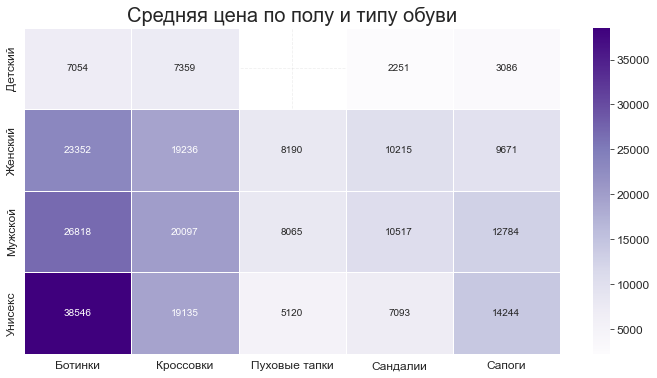

In [73]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_gend_type, annot=True, cmap='Purples', fmt='.0f', linewidths=0.5)
plt.title('Средняя цена по полу и типу обуви')
plt.ylabel('')
plt.xlabel('')
plt.show()

**Вывод:**  
- Ботинки — самый дорогой тип обуви во всех категориях, особенно в унисекс (38 546 руб.) и мужской (26 818 руб.).
- Кроссовки — цены близки во всех категориях (около 19 000–20 000 руб.), детские немного дешевле (7 359 руб.).
- Пуховые тапки (меньше 5 моделей в каждой категории) — отсутствуют в детской категории, цены близки у женской, мужской и унисекс (5 120–8 190 руб.).
- Сандалии и сапоги — дешевле ботинок и кроссовок, особенно в детской (2 251 руб. и 3 086 руб.).

### 2.3.2. Цена по полу и бренду

In [74]:
brand_counts = df['brand'].value_counts()
brands_to_keep = brand_counts[brand_counts >= 25].index
df_filtered = df[df['brand'].isin(brands_to_keep)]

In [75]:
print('Количество брендов с 25 и более моделями:', len(brands_to_keep))

Количество брендов с 25 и более моделями: 20


In [76]:
pivot_gend_brand = df_filtered.groupby(['brand', 'gender'])['price'].mean().round(2).unstack()
pivot_gend_brand['Разница Ж-М'] = pivot_gend_brand['Женский'] - pivot_gend_brand['Мужской']
pivot_gend_brand.sort_values('Разница Ж-М')

gender,Детский,Женский,Мужской,Унисекс,Разница Ж-М
brand,,,,,
Dolomite,NaN,15613.86,19020.82,19510.60,-3406.96
Asolo,NaN,28165.47,31181.67,12690.00,-3016.20
The North Face,NaN,12499.88,15151.54,27090.00,-2651.66
Brooks,NaN,16476.91,18980.00,NaN,-2503.09
Altra,NaN,20054.04,21992.87,NaN,-1938.83
Hanwag,NaN,29998.75,31862.00,NaN,-1863.25
Scarpa,13012.22,23629.61,25381.32,27875.67,-1751.71
Hoka,NaN,19451.00,21108.44,NaN,-1657.44
Meindl,NaN,28888.91,30230.86,26730.00,-1341.95


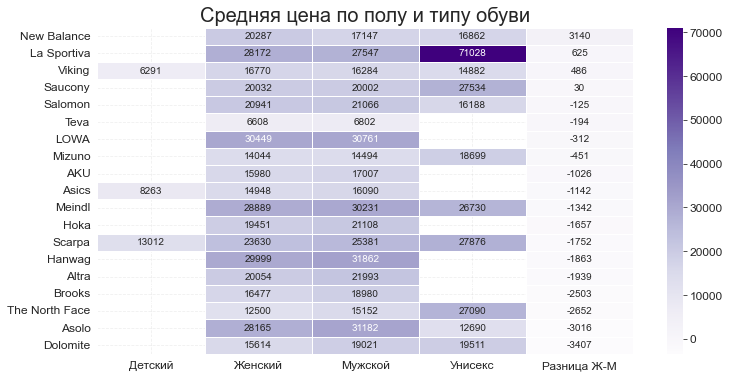

In [77]:
pivot_gend_brand_sort = pivot_gend_brand.sort_values('Разница Ж-М', ascending=False)
pivot_gend_brand_sort = pivot_gend_brand_sort.drop(index='Lassie')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_gend_brand_sort, annot=True, cmap='Purples', fmt='.0f', linewidths=0.5)
plt.title('Средняя цена по полу и типу обуви')
plt.ylabel('')
plt.xlabel('')
plt.show()

**Вывод:**  
- Среди брендов с количеством моделей более 25 (20 брендов) самыми дорогими являются мужские и женские модели Asolo, Hanwag, LOWA, La Sportiva, Meindl (средняя цена 27 500–32 000 руб).
- Цены на мужскую и женскую обувь внутри большинства брендов близки, однако у Dolomite,	Asolo, The North Face и Brooks мужские модели заметно дороже женских (на 2 500–3 400 руб), а у бренда New Balance, наоборот, женские модели дороже (более чем на 3 000 руб).
- У брендов Teva, Salomon, Saucony различия между мужской и женской обувью минимальны (менее 200 руб).
- Бренд La Sportiva выделяется аномально высокой ценой в категории унисекс (71 028 руб) — возможно, единичный дорогой товар.
- Бренд Lassie (чисто детский, средняя цена 3 837 руб) в анализ не включен из-за отсутствия других категорий.

### 2.3.3. Цена по типу и бренду

In [78]:
pivot_type_brand = df.groupby(['brand', 'type'])['price'].mean().round(2).unstack()
pivot_type_brand

type,Ботинки,Кроссовки,Пуховые тапки,Сандалии,Сапоги
brand,,,,,
AKU,16596.13,NaN,NaN,NaN,NaN
Adidas,5336.00,11211.00,NaN,NaN,NaN
Aigle,NaN,NaN,NaN,NaN,9601.78
Altra,NaN,21023.45,NaN,NaN,NaN
Anta,NaN,24363.33,NaN,NaN,NaN
Asics,NaN,14420.56,NaN,NaN,NaN
Asolo,30021.59,NaN,NaN,12690.00,NaN
Bask,NaN,NaN,5120.00,NaN,NaN
Bekina,NaN,NaN,NaN,NaN,11585.00


In [79]:
type_count = pivot_type_brand.count(axis=1)
single_type_brands = type_count[type_count == 1].index.tolist()
multi_type_brands = type_count[type_count >= 2].index.tolist()

In [80]:
pivot_filtered = pivot_type_brand.loc[multi_type_brands].sort_values('Ботинки', ascending=False)
pivot_filtered

type,Ботинки,Кроссовки,Пуховые тапки,Сандалии,Сапоги
brand,,,,,
La Sportiva,38118.24,23345.04,NaN,NaN,NaN
Asolo,30021.59,NaN,NaN,12690.00,NaN
Scarpa,25323.44,17583.75,NaN,NaN,NaN
Salomon,22760.86,20588.86,NaN,NaN,NaN
Hoka,21588.00,20146.93,NaN,NaN,NaN
Mammut,20752.67,27198.50,NaN,NaN,NaN
Garmont,20386.10,14888.00,NaN,NaN,NaN
Trezeta,11360.00,8180.00,NaN,NaN,NaN
Sorel,10630.67,NaN,NaN,NaN,9653.82


**Вывод:**  
- Многие бренды специализируются только на одном типе обуви. Например, ботинки — основной тип для 14 брендов (AKU, Bestard, Blackstone, Hanwag, Zamberlan и др.), кроссовки — для 11 брендов (Nike, Asics, Mizuno, Reebok и др.). Узкоспециализированные типы (пуховые тапки, сандалии, сапоги) представлены лишь 1–4 брендами каждый. Отдельной выделяется бренд The North Face, который представлен всеми типами обуви.
- Наибольшая средняя цена на ботинки у брендов: La Sportiva, Asolo, Scarpa (более 25 000 руб), на кроссовки — Mammut, La Sportiva, Salomon, Hoka (более 20 000 руб), на сандалии — Asolo и The North Face (более 10 000 руб), на сапоги — Viking (более 10 000 руб).

# 3. Гипотезы

## 3.1. Гипотеза №1. Скидки и количество размеров

**Для моделей с малым количеством моделей скидки выше.**

In [81]:
small_size = df[df['size_count'] <= 2]['discount_percent']
normal_size = df[df['size_count'] >= 3]['discount_percent']

print(f'Средняя скидка при 1–2 размерах: {small_size.mean():.1f}%')
print(f'Средняя скидка при 3+ размерах: {normal_size.mean():.1f}%')

Средняя скидка при 1–2 размерах: 25.0%
Средняя скидка при 3+ размерах: 7.2%


**Гипотеза №1 (подтвердилась)**  
Для моделей с малым количеством размеров (1–2 размера) средняя скидка составляет 25%. Это выше, чем у моделей с количеством размеров более 3, средняя скидка которых составляет 7,2%.

## 3.2. Гипотеза №2. Бренды с максимальной скидкой

**Бренды, у которых встречается скидка 60%, в целом предлагают мало скидочных моделей (или не делают скидки на другие свои модели).**

In [82]:
brands_with_60 = df[df['discount_percent'] == 60]['brand'].unique()
brands_without_60 = df[~df['brand'].isin(brands_with_60)]['brand'].unique()

In [83]:
count_60_brands = df[df['brand'].isin(brands_with_60) & (df['discount_percent'] > 0)].groupby('brand').size()
count_other_brands = df[df['brand'].isin(brands_without_60) & (df['discount_percent'] > 0)].groupby('brand').size()

In [84]:
print(f'Среднее количество скидочных моделей (бренды с 60%): {count_60_brands.mean():.1f}')
print(f'Среднее количество скидочных моделей (остальные): {count_other_brands.mean():.1f}')

Среднее количество скидочных моделей (бренды с 60%): 5.5
Среднее количество скидочных моделей (остальные): 13.1


**Гипотеза №2 (подтвердилась)**  
Бренды, предоставляющие скидку 60%, в среднем имеют 5,5 скидочных моделей, тогда как у остальных брендов этот показатель составляет 13,1.

## 3.3. Гипотеза №3. Популярные бренды и скидки

**Популярные бренды с большим количеством моделей имеют более низкую среднюю скидку.**

In [85]:
top_brands = df.groupby('brand')['brand'].count().sort_values(ascending=False).head(10).index
other_brands = df[~df['brand'].isin(top_brands)]['brand'].unique()

In [86]:
count_top_brands = df[df['brand'].isin(top_brands) & (df['discount_percent'] > 0)].groupby('brand')['discount_percent'].mean()
count_other_brands = df[df['brand'].isin(other_brands) & (df['discount_percent'] > 0)].groupby('brand')['discount_percent'].mean()

In [87]:
print(f'Средняя скидка популярных брендов: {count_top_brands.mean():.1f}%')
print(f'Средняя скидка непопулярных брендов: {count_other_brands.mean():.1f}%')

Средняя скидка популярных брендов: 33.1%
Средняя скидка непопулярных брендов: 41.3%


**Гипотеза №3 (подтвердилась)**  
Популярные бренды (топ-10 по количеству моделей) имеют более низкую среднюю скидку по сравнению с менее популярными брендами (33,1% против 41,3%).

## 3.4. Гипотеза №4. Узкоспециализированные бренды и скидки

**Бренды, специализирующиеся на одном типе обуви, дают более высокие скидки, чем мультибренды.**

In [88]:
df_disc = df[df['discount_percent'] > 0]
pivot_type_brand = df_disc.groupby(['brand', 'type'])['discount_percent'].mean().round(2).unstack()

In [89]:
type_count = pivot_type_brand.count(axis=1)
single_type_brands = type_count[type_count == 1].index.tolist()
multi_type_brands = type_count[type_count >= 2].index.tolist()

In [90]:
pivot_single_filtered = pivot_type_brand.loc[single_type_brands]
pivot_multi_filtered = pivot_type_brand.loc[multi_type_brands]

In [91]:
print(f'Средняя скидка на обувь мультибрендов: {pivot_multi_filtered.mean().mean().round(2)}%')
print(f'Средняя скидка на обувь узкоспециализированных брендов: {pivot_single_filtered.mean().mean().round(2)}%')

Средняя скидка на обувь мультибрендов: 44.16%
Средняя скидка на обувь узкоспециализированных брендов: 41.52%


**Гипотеза №4 (не подтвердилась)**  
Обувь мультибрендов имеет чуть более высокую среднюю скидку, чем обувь узкоспециализированных брендов (44,16% против 41,52%).

# 4. Итоги

## 4.1. Ассортимент и цены

### 4.1.1. Общая структура

| Показатель | Значение |
| --- | --- |
| Всего брендов | 48 |
| Типов обуви | 5 (кроссовки, ботинки, сандалии, сапоги, пуховые тапки) |
| Доля кроссовок и ботинок | >89% ассортимента (746 и 498 моделей) |
| Распределение по полу | Мужские — 45% (629), Женские — 39% (544), Детские и Унисекс — по 8% |

### 4.1.2. Цены

| Показатель | Цена (руб) |
| --- | --- |
| Средняя цена | 19 978 |
| Медианная цена | 19 290 |
| 90% товаров | от 5 248 до 35 990 |
| Выбросы (более 39 278 руб) | 45 моделей |

### 4.1.3. Самые дорогие и бюджетные бренды (10 и более моделей)

| Категория | Бренд | Средняя цена (руб) | Моделей |
| --- | --- | --- | --- |
| Самые дорогие | Zamberlan | 46 049 | 21 |
| | Hanwag | 31 117 | 40 |
| | Nike | 30 889 | 22 |
| Самые бюджетные | Joma | 2 515 | 11 |
| | Lassie | 3 837 | 44 |
| | Teva | 6 722 | 34 |

### 4.1.4. Цены по полу и типу обуви (средняя цена руб)

| Категория | Детская | Женская | Мужская | Унисекс |
| --- | --- | --- | --- | --- |
| Ботинки | 7 054 | 23 353 | 26 818 | 38 546 |
| Кроссовки | 7 359 | 19 236 | 20 097 | 19 135 |
| Сандалии | 2 251 | 10 215 | 10 517 | 7 093 |

*Детская обувь значительно дешевле взрослой (медиана 4 995 руб). Мужская и женская — близки (медианы 19 990 и 19 290 руб). Унисекс выделяется выбросами (медиана 18 204 руб, средняя 24 133 руб).*

### 4.1.5. Размеры

| Показатель | Значение |
| --- | --- |
| Всего размеров | 78 (диапазон 20–50) |
| Самые популярные | 42, 44, 42(1/2) |
| Самый полный размерный ряд | у кроссовок и ботинок (6+ размеров) |
| Бренды с самым широким рядом | Viking (20–47), Mizuno (36–50) |
| Бренды с одним размером | Kailas, Lomer |


## 4.2. Скидки и гипотезы

### 4.2.1. Общая статистика по скидкам

| Показатель | Значение |
| --- | --- |
| Доля товаров со скидкой | 32,5% (453 модели) |
| Диапазон скидок | 15–60% |
| Медианная скидка | 40% |
| Средняя скидка | 35,9% |
| Средняя скидка в рублях | 8 600 руб |
| Максимальная скидка | 60% (33 512 руб) |

### 4.2.2. Частота скидок по полу

| Категория | Доля товаров со скидкой | Средняя скидка | Медианная скидка |
| --- | --- | --- | --- |
| Детская | 54,4% | 48,2% | 50% |
| Женская | 33,8% | 34,8% | 30% |
| Мужская | 26,4% | 33,4% | 30% |
| Унисекс | 38,0% | 31,9% | 30% |

### 4.2.3. Частота скидок по брендам

| Показатель | Бренды |
| --- | --- |
| Чаще всего на скидках | Lassie (37), Mizuno (33), AKU (30) |
| Самая высокая средняя скидка (5 и более моделей) | Lassie (49,2%), Aigle (48,8%), Bestard (46,7%) |
| Бренды со скидкой 60% | Kamik, Viking, Reebok, Lomer, Kayland, Ecco |

### 4.2.4. Гипотезы

| № | Гипотеза | Результат | Ключевые цифры |
| --- | --- | --- | --- |
| 1 | Модели с малым количеством размеров имеют более высокие скидки | Подтвердилась | 25% (1–2 размера) против 7,2% (3+ размера) |
| 2 | Бренды со скидкой 60% имеют мало скидочных моделей | Подтвердилась | 5,5 против 13,1 (в 2,4 раза меньше) |
| 3 | Популярные бренды (топ-10) имеют более низкие скидки | Подтвердилась | 33,1% против 41,3% |
| 4 | Узкоспециализированные бренды имеют более высокие скидки | Не подтвердилась | 41,5% против 44,2% (обратная зависимость) |
